# Chemical Equilibrium III

[What is Bond listening to right now?](https://www.youtube.com/watch?v=v6alBpkeJN8&list=RDv6alBpkeJN8&start_radio=1)

This lecture begins our consideration of example problems so that we can get some practice with Chemical Equilibrium.

```{caution}
This Notebook uses Python for solving algebraic equations. Before proceeding, it is useful to have also reviewed [Notebook 02](https://jqbond.github.io/CEN587/Notebooks/587-N02.html), which covers Jupyter and Python basics and [Notebook 03](https://jqbond.github.io/CEN587/Notebooks/587-N03.html), which covers numerical solution of algebraic equations. Typically, these two Notebooks are covered as Recitation exercises in parallel to lecture content. They are adequate to build working competency with Python and numerical methods for solving algebraic equations, and we always cover them before solving equilibrium problems.

If you are interested in a more in depth explanation of Python skills required here, please review [Supplement 01 - The Basics](https://jqbond.github.io/CEN587/Supplements/587-S01.html), [Supplement 02 - Data Structures](https://jqbond.github.io/CEN587/Supplements/587-S02.html), [Supplement 03 - Arrays and Matrices](https://jqbond.github.io/CEN587/Supplements/587-S03.html), [Supplement 09 - Root Finding for Univariate Functions](https://jqbond.github.io/CEN587/Supplements/587-S09.html), and [Supplement 12 - Root Finding for Systems of (Multivariate) Equations](https://jqbond.github.io/CEN587/Supplements/587-S12.html).
```

In [13]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

## The Thermodynamics of Ammonia Synthesis

Consider the gas-phase reaction of molecular nitrogen with molecular hydrogen to produce ammonia:

$$N_2 (g) + 3H_2 (g) \leftrightharpoons 2N\!H_3 (g)$$

It is occuring in a batch reactor at 298K and 1 bar. This reaction is reversible such that, depending on the reaction conditions, ammonia decomposition may also occur favorably to form Hydrogen and Nitrogen. Before we even dig into solving problems with it, we'll ask a few concept questions about ammonia synthesis at these conditions $(T = 298\mathrm{K}, \ P = 1 \ \mathrm{bar})$.

```{tip}
When we consider equilibrium problems, we always need to be clear on our reference states.  This is a gas phase reaction occuring at 298K and 1 bar. Our reference state for gas phase species in chemical equilibrium problems is always species $j$ as a pure gas at the reaction temperature and 1 bar pressure. So, here, our standard state is pure species $j$ at 298K and 1 bar.
```
	
### Is the standard state reaction endothermic or exothermic?

To answer this question, we need to figure out the standard state enthalpy change of reaction, $\Delta H^\circ$.  This will be at 298K and 1 bar and based on pure, gas phase species reference states.  To facilitate, we can look up (or perhaps remember for $H_2$ and $N_2$), the following values (I looked up $N \! H_3$ data in Yaws' Handbook via Knovel:

|Species      | ${H_j}^\circ$ (kJ mol$^{-1}$)|
|-------------|:----------------------------:|
| $H_2$ (g)   | 0                            |
| $N_2$ (g)   | 0                            |
| $N\!H_3$ (g)| -45.90                       |

With this data in hand, it is straightforward to calculate a standard state reaction enthalpy using Hess' Law:

$$\Delta H^\circ = \sum_j \nu_j H_j^\circ =  2{H_{N\!H_3}}^\circ -{H_{N_2}}^\circ - 3{H_{H_2}}^\circ$$

That comes to:

$$\Delta H^\circ = -91.80 \ \textrm{kJ} \ \textrm{mol}^{-1}$$

This is actually a relatively exothermic reaction!  

```{important}
Negative values of $\Delta H$ are favorable from a thermodynamic perspective, so we would say that ammonia synthesis in the gas phase is ***enthalpically favorable*** at 298K and 1 bar.
```

The cell below is simply demonstrating the use of Python to compute and print the enthalpy change of reaction at the desired reaction conditions $(T = 298\mathrm{K}, \ P = 1 \ \mathrm{bar})$.

In [42]:
###############################################################################
# Define molar enthalpies and calculate ΔH of reaction at 298K                #
###############################################################################

HN2  = 0
HH2  = 0
HNH3 = -45.90 #kJ/mol
DH   = 2*HNH3 - HN2 - 3*HH2

###############################################################################
# Print the enthalpy of reaction; note use of formatted f string              #
# Make sure you understand the formatting codes like :4.2f                    #
###############################################################################

print(f'ΔH is {DH:6.2f} kJ/mole at 298K and 1 bar')

ΔH is -91.80 kJ/mole at 298K and 1 bar


### Does the reaction lead to an increase or decrease in entropy?  

We take a similar approach and look up entropy data in the standard state to calculate an entropy change of reaction. These values are added to our table below.

|Species      | ${H_j}^\circ \ (\mathrm{kJ \ mol^{-1}}$)| ${S_j}^\circ \ (\mathrm{J \ mol^{-1} \ K^{-1}}$) |
|-------------|:----------------------------:|:--------------------------------------|
| $N_2$ (g)   | 0                            |191.61                                 |
| $H_2$ (g)   | 0                            |130.68                                 |
| $N\!H_3$ (g)| -45.90                       |192.78                                 |

As above, we calculate the entropy change using Hess' law:

$$\Delta S^\circ = \sum_j \nu_j S_j^\circ = 2{S_{N\!H_3}}^\circ -{S_{N_2}}^\circ - 3{S_{H_2}}^\circ$$

And we find:

$$\Delta S^\circ = -198.09 \ \textrm{J} \ \textrm{mol}^{-1} \ \textrm{K}^{-1}$$

Wow!  This is a huge loss of entropy.  This is actually very unfavorable!  

```{important}
From an entropic perspective, ammonia synthesis at 298K and 1 bar is not favorable at all!
```

In [55]:
###############################################################################
# Define molar entropies and calculate ΔS of reaction at 298K                 #
###############################################################################

SN2  = 191.61 #J/mol/K
SH2  = 130.68 #J/mol/K
SNH3 = 192.78 #J/mol/K
DS   = 2*SNH3 - SN2 - 3*SH2 #J/mol/K

###############################################################################
# Print the entropy of reaction                                               #
###############################################################################

print(f'ΔS is {DS:7.2f} J/mol/K at 298K and 1 bar')

ΔS is -198.09 J/mol/K at 298K and 1 bar


### Is the reaction (thermodynamically) favorable at reaction conditions?

As we found above, ammonia synthesis at 298K and 1 bar is very favorable from an enthalpic perspective $(\Delta H^\circ = -91.8 \ \mathrm{kJ \ mol^{-1}})$ and very unfavorable from an entropic perspective $(\Delta S^\circ = -198.1$ J/mol/K). So how do we determine if the overall reaction is favorable?  We have to consider Gibbs free energy, which accounts for both enthalpic and entropic driving forces:

$$\Delta G = \Delta H - T \Delta S$$

Using this expression, we find:

$$\Delta G^\circ = \Delta H^\circ  - T \Delta S^\circ = -32,769 \ \textrm{J} \ \textrm{mol}^{-1} = -32.769 \ \textrm{kJ} \ \textrm{mol}^{-1}$$

This is an extremely favorable Gibbs free energy change!!!

```{caution}
The enthalpies that we looked up were in kJ/mol, and the entropies were in J/mol/K, so we have to convert accordingly to get the correct Gibbs free energy.  
```

Reactions with negative changes in Gibbs free energy are classified as "favorable." A Gibbs free energy change of less than maybe -50 kJ/mole is so favorable that we can essentially consider that reaction to be ***irreverisble***.  In other words, from a thermodynamic perspective, the reaction between $N_2$ and $H_2$ at 298K and 1 bar is ***extremely favorable***, and we should expect much more $N\!H_3$ than $N_2$ and $H_2$ once ammonia synthesis reaches chemical equilibrium at 298K and 1 bar.

In [56]:
###############################################################################
# Calculate ΔG of reaction at 298K                                            #
###############################################################################

T  = 298 #K
DG = DH*1000 - T*DS #J/mol

###############################################################################
# Print ΔG of reaction at 298K                                                #
###############################################################################

print(f'ΔG is {DG:5.0f} J/mol at 298K and 1 bar')

ΔG is -32769 J/mol at 298K and 1 bar


### What composition do I expect at chemical equilibrium? 

***(and what is the fractional conversion of $N_2$ at chemical equilibrium?)***

Without doing any calculations, just looking at that free energy change, I would expect mostly ammonia at chemical equilibrium.  This means that I'm expecting a high fractional conversion of $N_2$.  We can be a bit more quantitative by looking at the equilibrium constant, $K$, which gives us an idea of how favorable a reaction is.  For comparison, a reaction with $K = 1$ has a $\Delta G^\circ = 0$. It is thermoneutral and is neither favorable nor unfavorable. For an $A \leftrightharpoons B$ type reaction, if one calculates $K = 1$, then we would expect equal amounts of reactants and products at equilibrium (if starting with pure $A$).

#### Calculating the Equilibrium Constant

We calculate the equilibrium constant for this reaction using:

$$K = \exp\left(\frac{-\Delta G^\circ}{RT}\right)$$

In other words, we calculate the equilibrium constant at our standard state conditions for this reaction, where we know $\Delta G^\circ = -32,843 \ \mathrm{J mol^{-1}}$. Making appropriate substitutions $(T = 298\mathrm{K}$ and $R = 8.314 \ \mathrm{J \ mol^{-1} \ K^{-1}})$, we find:

$$K = 5.55\times10^5$$


```{note}
Consistent with our analysis of the Gibbs free energy change, this is extremely favorable! We should expect almost 100% conversion of $N_2$ at chemical equilibrium.
```

In [57]:
###############################################################################
# Calculate the equilibrium constant at 298K                                  #
###############################################################################

K = np.exp(-DG/8.314/298)
print(f'The Thermodynamic Equilibrium Constant for this reaction is K = {K:8.2E}')

The Thermodynamic Equilibrium Constant for this reaction is K = 5.55E+05


## Example Problem 01

Assume that a vessel (e.g., a batch reactor) is initially charged with $N_2$ and $H_2$ in a stoichiometric ratio (1:3).  The vessel is held at 298K and 1 bar. Calculate the composition of the gas-phase mixture and the fractional conversion of $N_2$ once the system reaches chemical equilibrium. As a reminder, fractional conversion of species $j$ is defined according to the equations below. We can always define a fractional conversion in terms of inlet and outlet moles. For a single reaction like this one, we can also define it in terms of the extent of reaction, $\varepsilon$.
	
$$X_j = \frac{N_{j_{0}} - N_{j}}{N_{j_{0}}} = \frac{-\nu_{j} \cdot \varepsilon}{N_{j_{0}}}$$
	
Further, we should recall that the extent of any single reaction can be formally defined in terms of any species participating in that reaction as below:
	
$$\varepsilon = \frac{N_j - N_{j_0}}{\nu_j}$$

### Solution to Example Problem 01

We want to solve for the equilibrium composition of a mixture, and we have thermodynamic data available. It therefore makes sense to start here:

$$\exp\left(\frac{-\Delta G^\circ}{RT}\right) = K = \prod_{j = 1}^{N_S}a_j^{\nu_j}$$

In the cells above, we solved for the standard state Gibbs Free Energy and the equilibrium constant for this reaction in its standard state (298K, 1 bar, pure gases reacting), and we found that:

$$K = 5.55\times10^5$$

Now we need to work through the right hand side of the equation and express thermodynamic activities in terms of species composition. We start here:

$$K = \prod_{j = 1}^{N_S}a_j^{\nu_j}$$

We apply this equation to the specific stoichiometry of ammonia synthesis to find:

$$K = \frac{{a_{N\!H_3}}^{2}}{{a_{N_2}}{a_{H_2}}^3}$$

From [Notebook 06](https://jqbond.github.io/CEN587/Notebooks/587-N06.html), we recall the definition for thermodynamic activities of gases in a mixture:

$$a_j = \frac{\hat{f}_j}{f_j^\circ}$$

The numerator is the fugacity of species $j$ under reaction conditions $(T = 298\mathrm{K}, \ P = 1 \ \mathrm{bar}, x_j = \, ?)$. The denominator is the fugacity of species $j$ in its standard state. Our standard state for gas-phase species is a pure species at 1 bar and the reaction temperature $(T = 298)$. Our convention for calculating fugacities of gases in a mixture uses the Lewis Randall rule. With these things in mind, formally, we have:

$$a_j = \frac{y_j \phi_j P}{y_j^\circ \phi_j^\circ  P^\circ}$$

Looking at the numerator of this Equation, we are operating this reactor at 1 bar, so the fugacity coefficient for species $j$ under reaction conditions, $\phi_j$ is 1. Looking at the denominator, the standard state is a pure species, so $y_j^\circ = 1$.  Further, that pure species is at 1 bar, so $\phi_j^\circ = 1$. This gives the usual result for low pressure gases:

$$a_j = \frac{y_j P}{P^\circ}$$

Now we apply this equation to all of the species participating in the reaction. Notice that we are still retaining $P$ and $P^\circ$ in the solution.  This helps to keep the expression general and extensible to other reaction conditions. Further, it reminds us to be dimensionally consistent. If we wanted to solve this equation by hand or in a calculator, we would probably start by substituting activity definitions to find:

$$K = \frac{\left(\frac{y_{N\!H_3}P}{P^\circ}\right)^2}{\left(\frac{y_{N_2}P}{P^\circ}\right) \left(\frac{y_{H_2}P}{P^\circ}\right)^3}$$

We see multiple pressures and reference pressures that will cancel, giving:

$$K = \frac{{y_{N\!H_3}}^2}{y_{N_2}{y_{H_2}}^3} \left(\frac{P^\circ}{P}\right)^2$$

Now we're at a point that we can't really go any further because we have 3 unknowns $(y_{N\!H_3}$, $y_{N_2}$, and $y_{H_2})$ and only 1 equation.  To go further, we need to relate mole fractions using stoichiometry. We do this with either a fractional conversion or a reaction extent. 

#### Expressing Mole Fractions as functions of Extent

The mole fraction for species $j$ in the gas phase, $y_j$, is defined as:

$$y_j = \frac{N_j}{N_{\textrm{total}}} = \frac{N_j}{\sum_j N_j}$$

Next, we express the moles of each species at any point in the reaction's progress, $N_j$, in terms of the extent of reaction(s) occuring in the system.  

$$N_j = N_{j,0} + \nu_j \varepsilon$$

We will do this for all species in the reactor. At this point, we can see that the total number of moles shows up in the definition of a mole fraction, so we need to track that quantity as well. It is best practice to develop the equations necessary to solve an equilibrium problem by organizing all of the relevant molar quantities in a mole table. For simplicity, we will relabel the compounds using $A$ $(N_2)$, $B$ $(H_2)$, and $C$ $(NH_3)$ for cleaner notation.

$$A (g) + 3B (g) \leftrightharpoons 2C (g)$$

|Species   |In        |Change           |End                     |
|:---------|:--------:|:---------------:|:----------------------:|
| $N_2$    |$N_{A0}$  |$-1\varepsilon$  |$N_{A0} - 1\varepsilon$ | 
| $H_2$    |$N_{B0}$  |$-3\varepsilon$  |$N_{B0} - 3\varepsilon$ |
| $N\!H_3$ |$N_{C0}$  |$+2\varepsilon$  |$N_{C0} + 2\varepsilon$ |
| Total    |$N_{T0}$  |$-2\varepsilon$  |$N_{T0} - 2\varepsilon$ |


We can make these substitutions into the definitions of mole fractions, ultimately finding:

$$K = \frac{\left(N_{C0} + 2\varepsilon\right)^2 \left(N_{T0} - 2\varepsilon\right)^2}{\left(N_{A0} - 1\varepsilon\right) \left(N_{B0} - 3\varepsilon\right)^3} \left(\frac{P^\circ}{P}\right)^2$$

#### Solve using numerical methods (this shows an ok approach...)

Inspection of this equation reveals that we know everything except for the extent of reaction. This means we have 1 Equation and 1 unknown, i.e., we need to find the root of a univariate function.  This can be solved with numerical methods; see below, we can use `scipy.optimize.newton()`. For convenience, we have aliased `scipy.optimize` as `opt`, so we can call this function using the syntax `opt.newton()`. In case it isn't clear, we are using `opt.newton()` here because it is an algorithm for finding roots of a univariate function, and here we have a univariate function because our only unknown is the extent of reaction, $\varepsilon$.

```{tip}
In the cell below, we are NOT plugging in numbers to the equation as you'd have to do to solve in a calculator. We are leaving it symbolic. This gives us much more flexibility because the solution is now general, and we can easily solve for different reaction pressures or different starting quantities of Nitrogen, Hydrogen, and Ammonia!
```

In [47]:
#######################################################################################
# Define the basis; here, an extensive basis is given in the problem statement        #
#######################################################################################

NA0 = 1 #mole of Nitrogen at start
NB0 = 3 #moles of Hydrogen at start
NC0 = 0 #moles of Ammonia at start
NT0 = NA0 + NB0 + NC0 #total moles at start

#######################################################################################
# Define the Reference Pressure, P0, and the system pressure, P, for this problem     #
#######################################################################################

P0 = 1 #bar
P  = 1 #bar

#######################################################################################
# Define the objective function to be solved using opt.newton()                       #
#######################################################################################

obj1 = lambda ex: (NC0 + 2*ex)**2 * (NT0 - 2*ex)**2 / (NA0 - ex) / (NB0 - 3*ex)**3 * P0**2 / P**2 - K

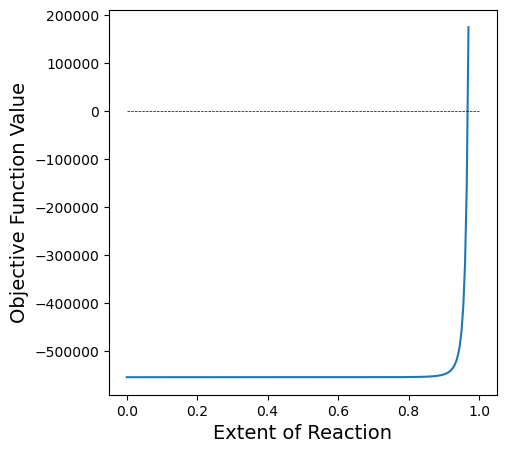

In [48]:
# Graphing the objective function
eset = np.linspace(0, 0.97, 200)
plt.figure(figsize = (5, 5))
plt.plot(eset, obj1(eset))
plt.hlines(0, 0, 1, linestyle = 'dashed', color = 'black', linewidth = 0.5)
plt.xlabel('Extent of Reaction', fontsize = 14)
plt.ylabel('Objective Function Value', fontsize = 14)
plt.show()

In [49]:
#######################################################################################
# Find the root of the objective function using opt.newton()                          #
#######################################################################################

ans, info = opt.newton(obj1, 0.98, full_output = True)

#######################################################################################
# Print the answer using a formatted f-string                                         #
#######################################################################################
print(f'The extent of reaction at Equilibrium is {ans:3.3f}')

The extent of reaction at Equilibrium is 0.968


#### Calculating composition and conversion

Now that we know the reaction extent at equilibrium, it is easy enough to calculate the composition of the mixture by evaluating the molar quantities using our mole table and substituting them into the definition of mole fractions:

In [50]:
########################################################################################################################
# This cell uses the solution for extent at equilibrium to compute the corresponding system composition at equilibrium #
########################################################################################################################

yA = (NA0 - ans)/(NT0 - 2*ans)
yB = (NB0 - 3*ans)/(NT0 - 2*ans)
yC = (NC0 + 2*ans)/(NT0 - 2*ans)
XA = ans/NA0

#######################################################################################################################
# Print calculated results using f strings                                                                            #
#######################################################################################################################

print(f'Mole fractions for N2, H2, and NH3 are {yA:3.3f}, {yB:3.3f}, {yC:3.3f}')
print(f'The fractional conversion of N2 is {XA:3.3f}')

Mole fractions for N2, H2, and NH3 are 0.016, 0.047, 0.938
The fractional conversion of N2 is 0.968


#### Solve using numerical methods (a better, more general approach?)

Once you become more comfortable with functions and numerical methods, you can actually make very general solutions like the one below. It is often preferable to structure codes this way because the equations in the code are easy to read and retain their their physical meaning. This makes it much easier to debug code that isn't working. In contrast, with the equation we solved above, it is difficult to recognize any specific terms, their physical meaning, whether values should be positive or negative, etc. This makes it hard to debug if something goes wrong.

```{tip}
Compare and contrast the equation definitions above and below.  Which do you find more readable and easier to understand?
```

In [52]:
####################################################################################################################################
# This is functionally equivalent to the above solution, but it offloads substitutions to Python instead of our doing them by hand #
####################################################################################################################################

####################################################################################################################################
# Build a univariate objective function called obj2(ex)                                                                            #
####################################################################################################################################

def obj2(ex):  #note "ex" is the the name given to the function argument inside of the function

    # Specifications for this problem
    K   = 5.55e5
    P   = 1.0 #bar
    P0  = 1.0 #bar
    NA0 = 1.0 #moles
    NB0 = 3.0 #moles
    NC0 = 0.0 #moles
    NT0 = NA0 + NB0 + NC0
    
    # mole table calculations
    NA  = NA0 - ex
    NB  = NB0 - 3*ex
    NC  = NC0 + 2*ex
    NT  = NA + NB + NC #This is equivalent to NT = NT0 - 2*ex
    
    # mole fraction calculations
    yA  = NA/NT
    yB  = NB/NT
    yC  = NC/NT
    
    # activity calculations
    aA  = yA*P/P0
    aB  = yB*P/P0
    aC  = yC*P/P0
    
    # Calculate equilibrium constant as prod(a_j^nu_j)
    KCOMP = aC**2/aA/aB**3 

    # Define equation that we are trying to solve
    LHS = KCOMP - K #We want to find the value of extent where KCOMP - K = 0; this is in a good form for opt.newton
    return LHS  

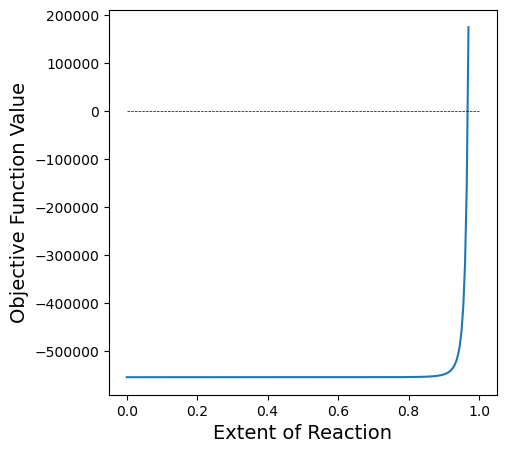

In [53]:
# Graphing the objective function
eset = np.linspace(0, 0.97, 200)
plt.figure(figsize = (5, 5))
plt.plot(eset, obj2(eset))
plt.hlines(0, 0, 1, linestyle = 'dashed', color = 'black', linewidth = 0.5)
plt.xlabel('Extent of Reaction', fontsize = 14)
plt.ylabel('Objective Function Value', fontsize = 14)
plt.show()

In [54]:
###############################################################################################
# Solve the univariate objective functioN obj2 using opt.newton()                             #
###############################################################################################

ans, info = opt.newton(obj2, 0.99, full_output = True) #This solves for the equilibrium extent

###############################################################################################
# print results and information                                                               #
############################################################################################### 
print(info, '\n') #Let's make sure it converged...

###############################################################################################
#Evaluate the mole table and solve for conversion and mole fractions at equilibrium           #
###############################################################################################
NA = NA0 - ans
NB = NB0 - 3*ans
NC = NC0 + 2*ans
NT = NA + NB + NC
XA = (NA0 - NA)/NA0
yA = NA/NT
yB = NB/NT
yC = NC/NT

###############################################################################################
# Print the answers                                                                           #
###############################################################################################
print(f'Conversion of N2 is {XA:3.3f}, yA is {yA:3.3f}, yB is {yB:3.3f}, and yC is {yC:3.3f}')

      converged: True
           flag: converged
 function_calls: 15
     iterations: 14
           root: 0.9678714190765809
         method: secant 

Conversion of N2 is 0.968, yA is 0.016, yB is 0.047, and yC is 0.938
